In [24]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
#Import the data from the provided URL and store it as a DataFrame
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data", header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])
#Print
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


df = pd.read_csv('/kaggle/input/iris/Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,Iris-setosa
1,3.0,1.4,0.2,Iris-setosa
2,3.2,1.3,0.2,Iris-setosa
3,3.1,1.5,0.2,Iris-setosa
4,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [9]:
df['species'] = encoder.fit_transform(df['species'])

In [10]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [11]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [12]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

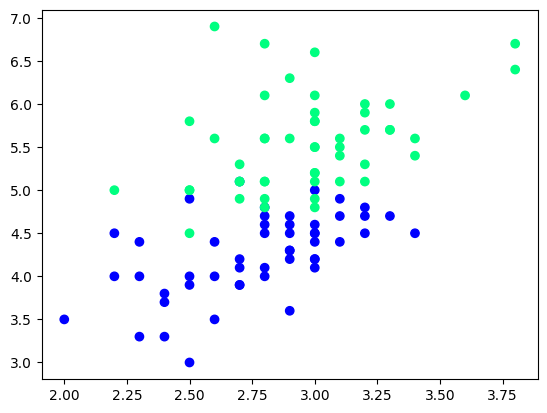

In [14]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [15]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
59,2.7,3.9,1
91,3.0,4.6,1
50,3.2,4.7,1
69,2.5,3.9,1
62,2.2,4.0,1
95,3.0,4.2,1
80,2.4,3.8,1
71,2.8,4.0,1
77,3.0,5.0,1
92,2.6,4.0,1


In [16]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [17]:
df_train

,sepal_width,petal_length,species
89,2.5,4.0,1
55,2.8,4.5,1
146,2.5,5.0,2
100,3.3,6.0,2
142,2.7,5.1,2
105,3.0,6.6,2
74,2.9,4.3,1
87,2.3,4.4,1
140,3.1,5.6,2
103,2.9,5.6,2


In [18]:
df_val

,sepal_width,petal_length,species
82,2.7,3.9,1
64,2.9,3.6,1
125,3.2,6.0,2
77,3.0,5.0,1
133,2.8,5.1,2


In [19]:
df_test

,sepal_width,petal_length,species
147,3.0,5.2,2
119,2.2,5.0,2
65,3.1,4.4,1
129,3.0,5.8,2
79,2.6,3.5,1


In [20]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [21]:
y_test

array([1, 1, 2, 1, 2])

# Case 1 - Bagging

In [22]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
103,2.9,5.6,2
100,3.3,6.0,2
105,3.0,6.6,2
89,2.5,4.0,1
142,2.7,5.1,2
142,2.7,5.1,2
105,3.0,6.6,2
74,2.9,4.3,1


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [26]:
dt_bag1 = DecisionTreeClassifier()

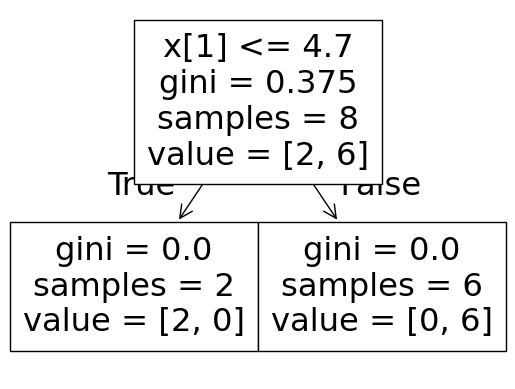

C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


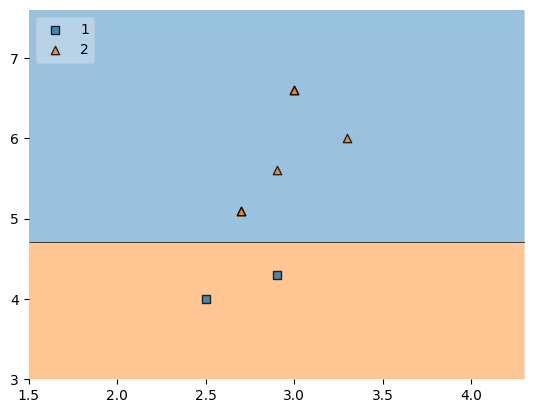

In [29]:
evaluate(dt_bag1,X,y)

In [30]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
146,2.5,5.0,2
146,2.5,5.0,2
105,3.0,6.6,2
142,2.7,5.1,2
140,3.1,5.6,2
103,2.9,5.6,2
146,2.5,5.0,2
55,2.8,4.5,1


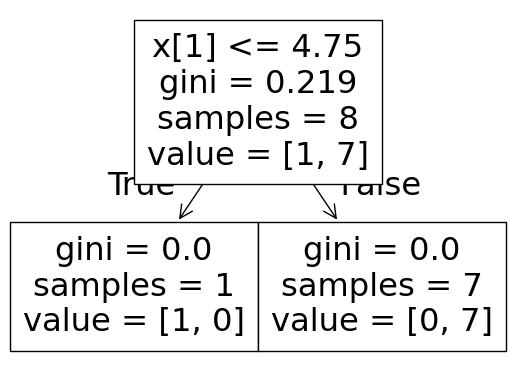

C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


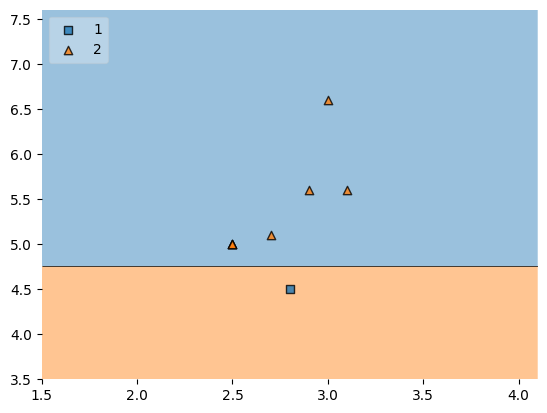

In [31]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [32]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
105,3.0,6.6,2
146,2.5,5.0,2
103,2.9,5.6,2
140,3.1,5.6,2
89,2.5,4.0,1
89,2.5,4.0,1
105,3.0,6.6,2
55,2.8,4.5,1


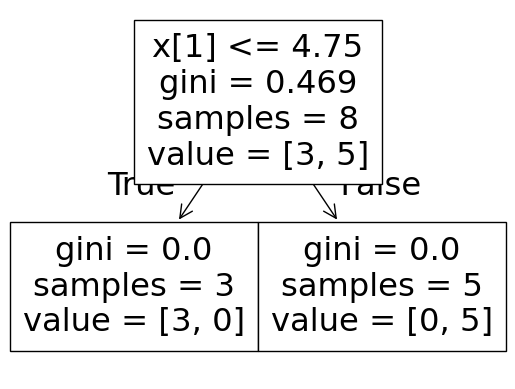

C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


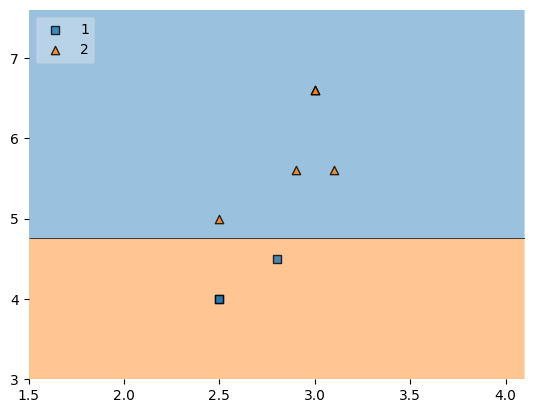

In [33]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [34]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [35]:
df_test

,sepal_width,petal_length,species
147,3.0,5.2,2
119,2.2,5.0,2
65,3.1,4.4,1
129,3.0,5.8,2
79,2.6,3.5,1


In [36]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [37]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
89,2.5,4.0,1
55,2.8,4.5,1
146,2.5,5.0,2
100,3.3,6.0,2
142,2.7,5.1,2
105,3.0,6.6,2
74,2.9,4.3,1
87,2.3,4.4,1
140,3.1,5.6,2
103,2.9,5.6,2


In [38]:
df_train.sample(8)

,sepal_width,petal_length,species
55,2.8,4.5,1
140,3.1,5.6,2
74,2.9,4.3,1
87,2.3,4.4,1
100,3.3,6.0,2
105,3.0,6.6,2
142,2.7,5.1,2
103,2.9,5.6,2


# Random Subspaces

In [60]:
df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df1 = df1.sample(10)

In [61]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
134,135,6.1,2.6,5.6,1.4,Iris-virginica
12,13,4.8,3.0,1.4,0.1,Iris-setosa
13,14,4.3,3.0,1.1,0.1,Iris-setosa
146,147,6.3,2.5,5.0,1.9,Iris-virginica
38,39,4.4,3.0,1.3,0.2,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
45,46,4.8,3.0,1.4,0.3,Iris-setosa
109,110,7.2,3.6,6.1,2.5,Iris-virginica
10,11,5.4,3.7,1.5,0.2,Iris-setosa


In [66]:
df1.sample(2,replace=True,axis=1)

,SepalWidthCm,Species
134,2.6,Iris-virginica
12,3.0,Iris-setosa
13,3.0,Iris-setosa
146,2.5,Iris-virginica
38,3.0,Iris-setosa
62,2.2,Iris-versicolor
77,3.0,Iris-versicolor
45,3.0,Iris-setosa
109,3.6,Iris-virginica
10,3.7,Iris-setosa


# Random Patches

In [67]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
134,135,6.1,2.6,5.6,1.4,Iris-virginica
12,13,4.8,3.0,1.4,0.1,Iris-setosa
13,14,4.3,3.0,1.1,0.1,Iris-setosa
146,147,6.3,2.5,5.0,1.9,Iris-virginica
38,39,4.4,3.0,1.3,0.2,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
45,46,4.8,3.0,1.4,0.3,Iris-setosa
109,110,7.2,3.6,6.1,2.5,Iris-virginica
10,11,5.4,3.7,1.5,0.2,Iris-setosa


In [69]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalLengthCm,Id
38,4.4,39
10,5.4,11
109,7.2,110
62,6.0,63
134,6.1,135
12,4.8,13
10,5.4,11
134,6.1,135
